In [169]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
import glob
import os

plt.style.use("seaborn-v0_8")


In [170]:
# --- corrected room dimensions from direct measurements ---
# Bedroom: square room, 505 cm x 505 cm
# Geolab: 225 cm x 635 cm
ROOM_DIMS = {
    "bedroom": {"Lx": 5.05, "Ly": 5.05, "H": 2.30},
    "geolab":  {"Lx": 2.25, "Ly": 6.35, "H": 2.30},
}

BEDROOM_LX = ROOM_DIMS["bedroom"]["Lx"]
BEDROOM_LY = ROOM_DIMS["bedroom"]["Ly"]
GEOLAB_LX = ROOM_DIMS["geolab"]["Lx"]
GEOLAB_LY = ROOM_DIMS["geolab"]["Ly"]
ROOM_HEIGHT = ROOM_DIMS["bedroom"]["H"]

print("Corrected dimensions loaded:")
for room, dims in ROOM_DIMS.items():
    print(f"{room}: {dims['Lx']} m x {dims['Ly']} m x {dims['H']} m")

Corrected dimensions loaded:
bedroom: 5.05 m x 5.05 m x 2.3 m
geolab: 2.25 m x 6.35 m x 2.3 m


In [171]:
# Path to your folder
DATA_PATH = "/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors"

# Find all CSV files inside the folder
files = glob.glob(os.path.join(DATA_PATH, "*.csv"))

print("Found files:", files)


Found files: ['/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N41.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N42.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N22.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N36.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N23.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N35.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N20.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N34.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N30.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N33.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N32.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N26.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N28.csv', '/Users/nataliakowalczyk/CLionProjects/Habitat_1/Sensors/N39.csv']


In [172]:
def load_sensor_csv(path):
    # Read two-column CSV without header
    df = pd.read_csv(
        path,
        header=None,
        names=["time", "temp_raw"],
        sep=",",
        engine="python"
    )

    # Convert time column
    df["time"] = pd.to_datetime(df["time"], errors="coerce")

    # Clean temperature: remove units like "°C" or spaces
    df["temp"] = (
        df["temp_raw"]
        .astype(str)
        .str.replace("°C", "", regex=False)
        .str.replace("° C", "", regex=False)
        .str.replace("C", "", regex=False)
        .str.replace("°", "", regex=False)
        .str.strip()
    )

    # Convert to float
    df["temp"] = pd.to_numeric(df["temp"], errors="coerce")

    # Drop missing
    df = df.dropna(subset=["time", "temp"])

    # Set time as index
    df = df.set_index("time").sort_index()

    return df[["temp"]]

In [173]:
def unify_time_index(sensor_dict, freq="10min"):
    """
    Resamples each sensor to a common time grid and aligns all sensors.
    """
    # Create union of all timestamps across sensors
    full_index = None
    for df in sensor_dict.values():
        if full_index is None:
            full_index = df.index
        else:
            full_index = full_index.union(df.index)

    # Resample to regular grid
    regular_index = full_index.sort_values().to_series().resample(freq).first().index

    out = {}
    for sid, df in sensor_dict.items():
        out[sid] = (
            df.resample(freq).mean().reindex(regular_index)
        )
    return out


In [174]:
geolab_1m  = ["N28", "N36", "N26", "N41"]
geolab_2m  = ["N23", "N39", "N34", "N42"]

bed_1m = ["N33", "N35", "N30"]
bed_2m = ["N32", "N22", "N20"]

ROOMS = {
    "geolab": {"1m": geolab_1m, "2m": geolab_2m},
    "bedroom": {"1m": bed_1m, "2m": bed_2m}
}

In [175]:
def compute_room_temperature(room, mapping):
    df = pd.DataFrame()

    # merge & average 1m sensors
    df1_list = [sensor_data[s] for s in mapping[room]["1m"]]
    df["T1m"] = pd.concat(df1_list, axis=1).mean(axis=1)

    # merge & average 2m sensors
    df2_list = [sensor_data[s] for s in mapping[room]["2m"]]
    df["T2m"] = pd.concat(df2_list, axis=1).mean(axis=1)

    df["dT"] = df["T2m"] - df["T1m"]
    return df


In [176]:
# 1. Load all sensors into a dict
sensor_data = {}

for f in files:
    sensor_id = os.path.splitext(os.path.basename(f))[0]   # e.g. "N41"
    sensor_data[sensor_id] = load_sensor_csv(f)

print("Loaded sensors:", sensor_data.keys())

# 2. Put all sensors on the same 10-minute time grid
sensor_data = unify_time_index(sensor_data, freq="10min")

# 3. Now compute room temperatures
geolab  = compute_room_temperature("geolab", ROOMS)
bedroom = compute_room_temperature("bedroom", ROOMS)

geolab.tail(), bedroom.tail()

Loaded sensors: dict_keys(['N41', 'N42', 'N22', 'N36', 'N23', 'N35', 'N20', 'N34', 'N30', 'N33', 'N32', 'N26', 'N28', 'N39'])


(                           T1m    T2m        dT
 time                                           
 2025-12-03 15:20:00  22.266667  22.90  0.633333
 2025-12-03 15:30:00  22.033333  22.65  0.616667
 2025-12-03 15:40:00  21.800000  22.45  0.650000
 2025-12-03 15:50:00  21.600000  22.25  0.650000
 2025-12-03 16:00:00  22.300000  22.10 -0.200000,
                            T1m        T2m        dT
 time                                               
 2025-12-03 15:20:00  23.350000  23.700000  0.350000
 2025-12-03 15:30:00  22.833333  23.300000  0.466667
 2025-12-03 15:40:00  22.466667  22.966667  0.500000
 2025-12-03 15:50:00  22.200000  22.733333  0.533333
 2025-12-03 16:00:00  21.950000  22.450000  0.500000)

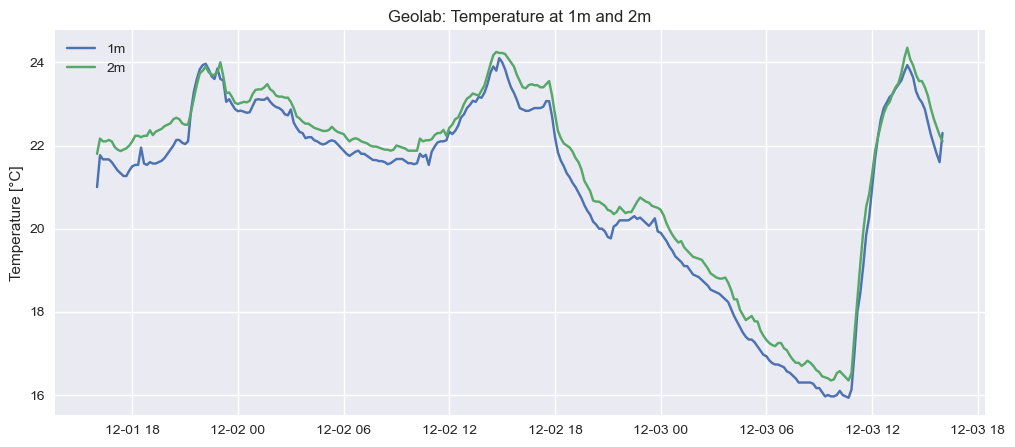

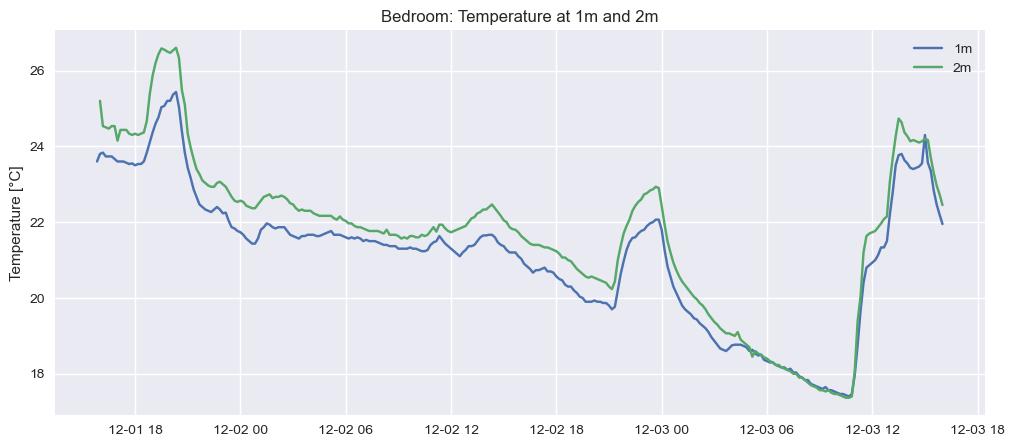

In [177]:
def plot_room(room_name, df):
    plt.figure(figsize=(12,5))
    plt.plot(df.index, df["T1m"], label="1m")
    plt.plot(df.index, df["T2m"], label="2m")
    plt.title(f"{room_name}: Temperature at 1m and 2m")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    plt.savefig(f"{room_name}_temperature.png")
    plt.show()

plot_room("Geolab", geolab)
plot_room("Bedroom", bedroom)

In [178]:
def detect_events(df, smoothing=11):
    # differentiate and smooth
    dt = (df.index[1] - df.index[0]).total_seconds() / 60.0  # minutes
    dTdt = savgol_filter(df["T1m"].diff() / dt, 11, 3)

    # threshold
    heat_on = df.index[dTdt > 0.01]      # warming
    heat_off = df.index[dTdt < -0.01]    # cooling

    return heat_on, heat_off, dTdt

heat_on_geo, heat_off_geo, dTdt_geo = detect_events(geolab)
heat_on_bed, heat_off_bed, dTdt_bed = detect_events(bedroom)

heat_on_geo[:25], heat_off_geo[:5]

(DatetimeIndex(['2025-12-01 20:00:00', '2025-12-01 21:00:00',
                '2025-12-01 21:10:00', '2025-12-01 21:20:00',
                '2025-12-01 21:30:00', '2025-12-01 21:40:00',
                '2025-12-01 21:50:00', '2025-12-01 22:00:00',
                '2025-12-02 12:30:00', '2025-12-02 12:40:00',
                '2025-12-02 12:50:00', '2025-12-02 13:00:00',
                '2025-12-02 13:50:00', '2025-12-02 14:00:00',
                '2025-12-02 14:10:00', '2025-12-02 14:20:00',
                '2025-12-02 14:30:00', '2025-12-02 14:40:00',
                '2025-12-03 10:40:00', '2025-12-03 10:50:00',
                '2025-12-03 11:00:00', '2025-12-03 11:10:00',
                '2025-12-03 11:20:00', '2025-12-03 11:30:00',
                '2025-12-03 11:40:00'],
               dtype='datetime64[ns]', name='time', freq=None),
 DatetimeIndex(['2025-12-01 17:00:00', '2025-12-01 22:50:00',
                '2025-12-01 23:00:00', '2025-12-01 23:10:00',
                '2025-12-01 

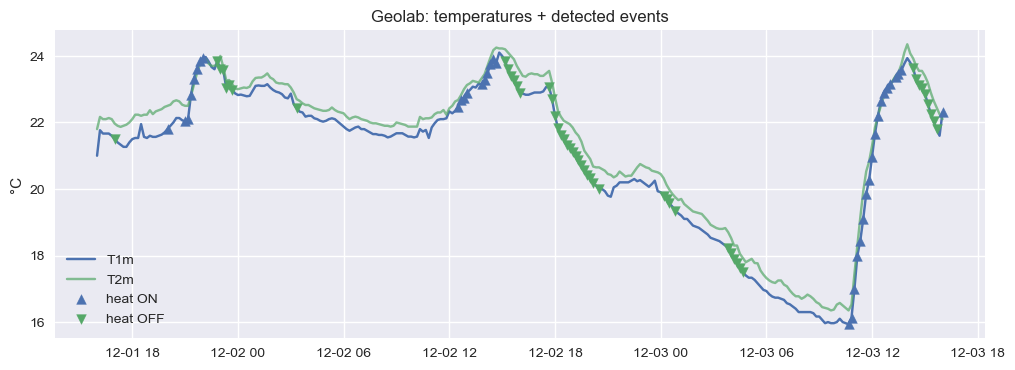

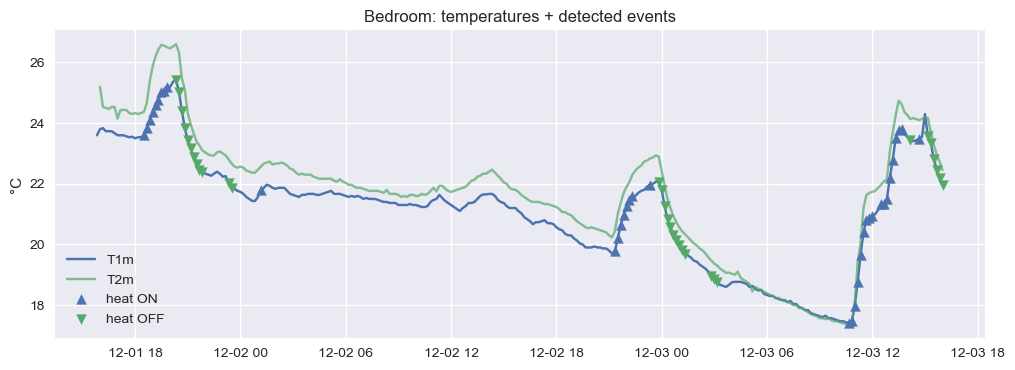

In [179]:
def plot_events(df, dTdt, heat_on, heat_off, room_name):
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df["T1m"], label="T1m")
    plt.plot(df.index, df["T2m"], label="T2m", alpha=0.7)
    plt.scatter(heat_on, df.loc[heat_on,"T1m"], marker="^", label="heat ON", zorder=5)
    plt.scatter(heat_off, df.loc[heat_off,"T1m"], marker="v", label="heat OFF", zorder=5)
    plt.legend()
    plt.title(f"{room_name}: temperatures + detected events")
    plt.ylabel("°C")
    plt.savefig(f"{room_name}_events.png")
    plt.show()

plot_events(geolab, dTdt_geo, heat_on_geo, heat_off_geo, "Geolab")
plot_events(bedroom, dTdt_bed, heat_on_bed, heat_off_bed, "Bedroom")

In [180]:
# --- outside-temperature stability check ---
# Feedback note: the exponential time-constant fits assume approximately constant outside temperature T_inf.
# If one of the CSV files corresponds to an outside sensor, put its ID below, e.g. OUTSIDE_SENSOR_ID = "Nxx".
# If no outside sensor is available in this dataset, this cell safely skips the check.

OUTSIDE_SENSOR_ID = None  # change to the correct outdoor sensor ID if available

if OUTSIDE_SENSOR_ID in sensor_data:
    outside_temp = sensor_data[OUTSIDE_SENSOR_ID]["temp"].resample("10min").mean().interpolate()

    plt.figure(figsize=(12, 4))
    plt.plot(outside_temp.index, outside_temp, label=f"Outside temperature ({OUTSIDE_SENSOR_ID})")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.title("Outside temperature stability check")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig("outside_temperature_stability.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("Outside temperature mean [°C]:", outside_temp.mean())
    print("Outside temperature std [°C]:", outside_temp.std())
    print("Outside temperature range [°C]:", outside_temp.max() - outside_temp.min())
else:
    print("No outside sensor selected. Set OUTSIDE_SENSOR_ID to the outdoor sensor name if present in the data.")

No outside sensor selected. Set OUTSIDE_SENSOR_ID to the outdoor sensor name if present in the data.


In [181]:
t0_bed = heat_on_bed[20]
print("Heating turns on at:", t0_bed)

Heating turns on at: 2025-12-03 11:00:00


In [182]:
t_off_bed = heat_off_bed[12]
print("Heating turns off at:", t_off_bed)

Heating turns off at: 2025-12-02 23:50:00


In [183]:
t_off_geo = heat_off_geo[15]
print("Heating turns on at:", t_off_geo)

Heating turns on at: 2025-12-02 17:50:00


In [184]:
def extract_warmup_segment(df, t_on, duration="1h"):
    t_end = t_on + pd.Timedelta(duration)
    seg = df[(df.index >= t_on) & (df.index <= t_end)].copy()
    return seg

In [185]:
def warmup_model(t, T_max, T_inf, tau):
    """
    Warm-up model suggested in feedback:
    T(0) = T_inf, T(infinity) = T_max.

    t is in minutes, tau is in minutes.
    """
    return T_max + (T_inf - T_max) * np.exp(-t / tau)


def cooldown_model(t, T_inf, T_max, tau):
    """
    Cool-down model suggested in feedback:
    T(0) = T_max, T(infinity) = T_inf.

    t is in minutes, tau is in minutes.
    """
    return T_inf + (T_max - T_inf) * np.exp(-t / tau)

In [186]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def fit_thermal_time_constant(df, t_on, duration="3h"):
    """Fit corrected warm-up model and return tau_warm in minutes."""
    seg = extract_warmup_segment(df, t_on, duration)

    # time in minutes from heater ON
    t = (seg.index - seg.index[0]).total_seconds() / 60.0
    T = seg["T1m"].values

    # corrected model: T(t)=T_max+(T_inf-T_max)exp(-t/tau)
    T_inf_guess = T[0]
    T_max_guess = T[-1]
    tau_guess = max((t.max() - t.min()) / 2, 1.0)
    p0 = [T_max_guess, T_inf_guess, tau_guess]

    bounds = ([min(T) - 10, min(T) - 10, 1e-6],
              [max(T) + 20, max(T) + 10, np.inf])

    popt, pcov = curve_fit(warmup_model, t, T, p0=p0, bounds=bounds, maxfev=20000)
    T_max, T_inf, tau = popt

    # Plot result
    t_fit = np.linspace(t.min(), t.max(), 200)
    T_fit = warmup_model(t_fit, T_max, T_inf, tau)

    plt.figure(figsize=(8, 4))
    plt.scatter(t, T, s=12, label="data")
    plt.plot(t_fit, T_fit, label=f"fit: τ_warm = {tau:.1f} min")
    plt.xlabel("t [min]")
    plt.ylabel("T1m [°C]")
    plt.title(f"Thermal warm-up fit starting at {t_on}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(f"warmup_{t_on}.png", dpi=200, bbox_inches="tight")
    plt.show()

    return tau, (T_max, T_inf, tau)

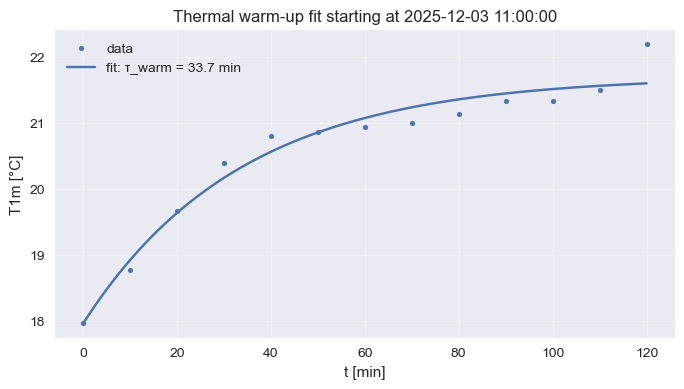

Bedroom τ_heat ≈ 33.70035258265632 min


In [187]:
tau_bed, params_bed = fit_thermal_time_constant(bedroom, t0_bed, duration="2h")
print("Bedroom τ_heat ≈", tau_bed, "min")

Heating turns on at: 2025-12-03 11:50:00


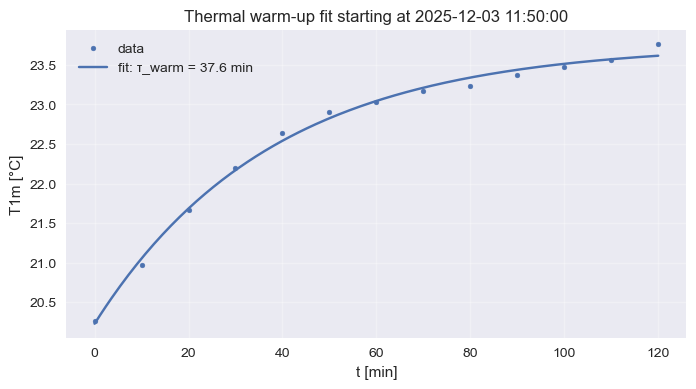

Geolab τ_heat ≈ 37.63271937068266 min


In [188]:
t0_geo = heat_on_geo[25]
print("Heating turns on at:", t0_geo)

tau_geo, params_geo = fit_thermal_time_constant(geolab, t0_geo, duration="2h")
print("Geolab τ_heat ≈", tau_geo, "min")

In [189]:
def extract_cooldown_segment(df, t_off, duration="1h"):
    t_end = t_off + pd.Timedelta(duration)
    seg = df[(df.index >= t_off) & (df.index <= t_end)].copy()
    return seg

In [190]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def fit_cool_time_constant(df, t_off, duration="9h"):
    """Fit corrected cool-down model and return tau_cool in minutes."""
    seg = extract_cooldown_segment(df, t_off, duration)

    t = (seg.index - seg.index[0]).total_seconds() / 60.0  # minutes
    T = seg["T1m"].values

    # corrected model: T(t)=T_inf+(T_max-T_inf)exp(-t/tau)
    T_max_guess = T[0]
    T_inf_guess = T[-1]
    tau_guess = max((t.max() - t.min()) / 2, 1.0)
    p0 = [T_inf_guess, T_max_guess, tau_guess]

    bounds = ([min(T) - 20, min(T) - 10, 1e-6],
              [max(T) + 10, max(T) + 20, np.inf])

    popt, pcov = curve_fit(cooldown_model, t, T, p0=p0, bounds=bounds, maxfev=20000)
    T_inf, T_max, tau = popt

    # plot
    t_fit = np.linspace(t.min(), t.max(), 200)
    T_fit = cooldown_model(t_fit, T_inf, T_max, tau)

    plt.figure(figsize=(8, 4))
    plt.scatter(t, T, s=12, label="data")
    plt.plot(t_fit, T_fit, label=f"fit: τ_cool = {tau:.1f} min")
    plt.xlabel("t [min]")
    plt.ylabel("T1m [°C]")
    plt.title(f"Thermal cooldown fit starting at {t_off}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(f"cooldown_{t_off}.png", dpi=200, bbox_inches="tight")
    plt.show()

    return tau, (T_inf, T_max, tau)

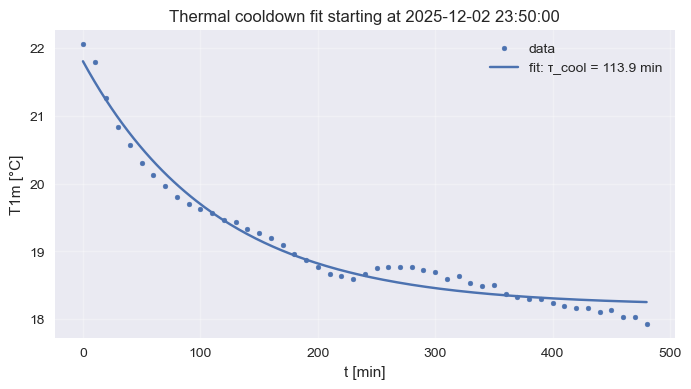

Bedroom τ_cool ≈ 113.92554783392788 min


In [191]:
tau_cool_bed, params_cool_bed = fit_cool_time_constant(bedroom, t_off_bed, duration="8h")
print("Bedroom τ_cool ≈", tau_cool_bed, "min")

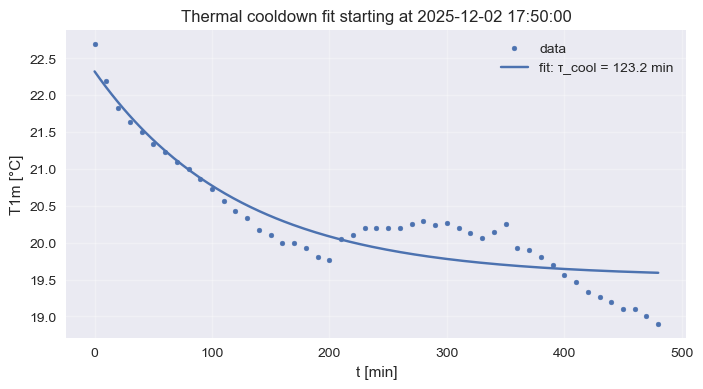

Geolab τ_cool ≈ 123.17074274147146 min


In [192]:
tau_cool_geo, params_cool_geo = fit_cool_time_constant(geolab, t_off_geo, duration="8h")
print("Geolab τ_cool ≈", tau_cool_geo, "min")

In [193]:
def compute_boundary_h(Lx, Ly, H, tau_cool, rho=1.2, cp=1000):
    # 1. Room volume
    V = Lx * Ly * H  # m³

    # 2. Thermal capacity of air inside room
    C = rho * cp * V  # J/K

    # 3. Global heat loss rate
    H_loss = C / tau_cool  # W/K

    # 4. Envelope area = walls + floor + ceiling
    A_env = 2*(Lx*Ly) + 2*(Lx*H + Ly*H)  # m²

    # 5. Effective boundary coefficient
    h = H_loss / A_env  # W/m²K

    return h


In [194]:
h_bedroom = compute_boundary_h(BEDROOM_LX, BEDROOM_LY, ROOM_HEIGHT, tau_cool_bed*60)
print("h for Bedroom is", h_bedroom, "W/m²K")

h_geolab = compute_boundary_h(GEOLAB_LX, GEOLAB_LY, ROOM_HEIGHT, tau_cool_geo*60)
print("h for Geolab is", h_geolab, "W/m²K")

h for Bedroom is 0.10565030986374878 W/m²K
h for Geolab is 0.07831343157852333 W/m²K


In [195]:
import math

def estimate_diffusivity_D(Lx, Ly, tau_warm):
    # Effective length scale of 2D room
    L_eff = math.sqrt(Lx**2 + Ly**2)

    # Estimate D from analytical inversion
    D = (L_eff**2) / (math.pi**2 * tau_warm)

    return D


In [196]:
D_bedroom = estimate_diffusivity_D(4.0, 4.5, tau_bed*60)
print("Estimated D for Bedroom is", D_bedroom, "m²/s")

D_geolab = estimate_diffusivity_D(2.0, 5.0, tau_geo*60)
print("Estimated D for Geolab is", D_geolab, "m²/s")

Estimated D for Bedroom is 0.0018164463304581645 m²/s
Estimated D for Geolab is 0.0013013118968298882 m²/s


In [197]:
import math

def compute_Smax(Lx, Ly, H, P_heater, r_heater,
                 rho=1.2, cp=1000):
    # ---- Room total thermal capacity ----
    V = Lx * Ly * H                  # room volume (m³)
    C = rho * cp * V                 # heat capacity (J/K)

    # ---- Average heating rate (if uniform) ----
    S_avg = P_heater / C             # K/s

    # ---- Floor areas ----
    A_room    = Lx * Ly              # total floor area (m²)
    A_heater  = math.pi * r_heater**2

    # ---- Scale to match simulation-localized source ----
    Smax = S_avg * (A_room / A_heater)

    return Smax


In [198]:
Smax_bedroom = compute_Smax(
    Lx=BEDROOM_LX, Ly=BEDROOM_LY, H=ROOM_HEIGHT,        # room dimensions
    P_heater=2000,                # 2000W heater
    r_heater=0.20                 # 20cm heater radius like in your C++ code
)

print("Estimated Smax for Bedroom", Smax_bedroom, "K/s")

Smax_geolab = compute_Smax(
    Lx=GEOLAB_LX, Ly=GEOLAB_LY, H=ROOM_HEIGHT,
    P_heater=2000, r_heater=0.20
)
print("Estimated Smax for Geolab", Smax_geolab, "K/s")

Estimated Smax for Bedroom 5.766483445358526 K/s
Estimated Smax for Geolab 5.766483445358526 K/s


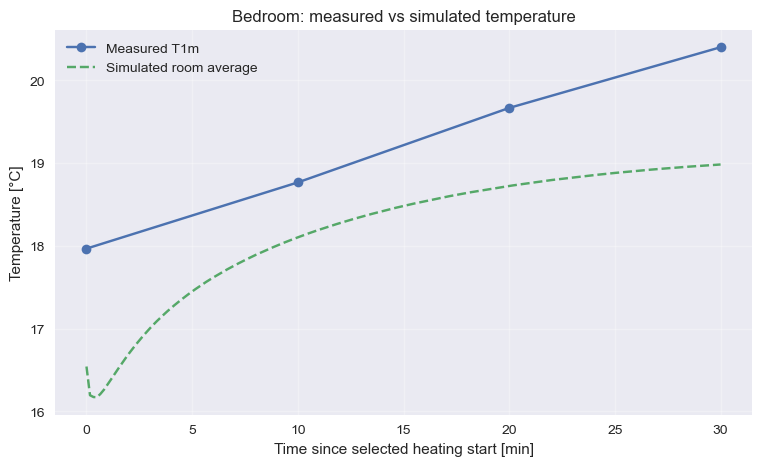

Bedroom RMSE: 1.158 °C
Bedroom MAE:  1.112 °C


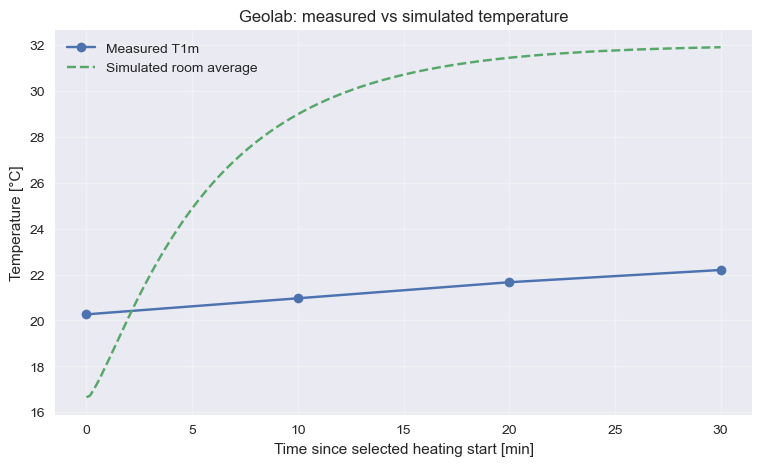

Geolab RMSE: 8.177 °C
Geolab MAE:  7.783 °C


[{'room': 'Bedroom',
  'RMSE_C': np.float64(1.1583002633168802),
  'MAE_C': np.float64(1.1119999999999788)},
 {'room': 'Geolab',
  'RMSE_C': np.float64(8.17743094844993),
  'MAE_C': np.float64(7.7830833333333365)}]

In [199]:
# --- measured-vs-simulated validation plot ---
# Run the corrected C++ programs first so these files exist:
#   bedroom/average_temperature.dat
#   geolab/average_temperature.dat

from pathlib import Path


def load_simulated_average(path):
    path = Path(path)
    if not path.exists():
        print(f"Missing simulation file: {path}")
        return None

    arr = np.loadtxt(path)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    t_seconds = arr[:, 0]
    T_sim = arr[:, 1]

    # C++ writes Kelvin. Convert to Celsius if needed.
    if np.nanmean(T_sim) > 100:
        T_sim = T_sim - 273.15

    return t_seconds / 60.0, T_sim


def compare_measured_and_simulated(room_df, t_start, sim_path, room_name):
    loaded = load_simulated_average(sim_path)
    if loaded is None:
        return None

    t_sim_min, T_sim = loaded

    # Compare against measured 1 m temperature after the same heating-start timestamp.
    measured_segment = room_df[(room_df.index >= t_start) &
                               (room_df.index <= t_start + pd.to_timedelta(t_sim_min.max(), unit="min"))].copy()
    if measured_segment.empty:
        print(f"No measured data found for {room_name} in selected time window.")
        return None

    t_meas_min = (measured_segment.index - t_start).total_seconds() / 60.0
    T_meas = measured_segment["T1m"].values

    # Interpolate simulation to measurement timestamps for metrics.
    T_sim_interp = np.interp(t_meas_min, t_sim_min, T_sim)
    rmse = np.sqrt(np.mean((T_sim_interp - T_meas) ** 2))
    mae = np.mean(np.abs(T_sim_interp - T_meas))

    plt.figure(figsize=(9, 5))
    plt.plot(t_meas_min, T_meas, "o-", label="Measured T1m")
    plt.plot(t_sim_min, T_sim, "--", label="Simulated room average")
    plt.xlabel("Time since selected heating start [min]")
    plt.ylabel("Temperature [°C]")
    plt.title(f"{room_name}: measured vs simulated temperature")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(f"{room_name.lower()}_measured_vs_simulated.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"{room_name} RMSE: {rmse:.3f} °C")
    print(f"{room_name} MAE:  {mae:.3f} °C")
    return {"room": room_name, "RMSE_C": rmse, "MAE_C": mae}


validation_results = []
result = compare_measured_and_simulated(bedroom, t0_bed, "/Users/nataliakowalczyk/CLionProjects/Habitat_1/cmake-build-debug/bedroom/average_temperature.dat", "Bedroom")
if result is not None:
    validation_results.append(result)

result = compare_measured_and_simulated(geolab, t0_geo, "/Users/nataliakowalczyk/CLionProjects/Habitat_1/cmake-build-debug/geolab/average_temperature.dat", "Geolab")
if result is not None:
    validation_results.append(result)

validation_results